<a href="https://colab.research.google.com/github/marcehluna/DVxC---Aprendizaje-Profundo---TP3/blob/main/Luna-Marcelo-DL-TP3-CO24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Luna Marcelo - Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [1]:
import os
import subprocess
import sys
import zipfile
from pathlib import Path

IN_COLAB = os.path.exists("/content") and os.environ.get("COLAB_RELEASE_TAG") is not None


def _pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])


def _ensure_packages(packages):
    missing = []
    for module, package in packages:
        try:
            __import__(module)
        except ModuleNotFoundError:
            missing.append(package)
    if missing:
        _pip_install(*missing)


_ensure_packages([
    ("matplotlib", "matplotlib"),
    ("numpy", "numpy"),
    ("PIL", "pillow"),
])

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def _importar_torch():
    import torch
    from torch.utils.data import WeightedRandomSampler
    from torchvision import transforms
    return torch, WeightedRandomSampler, transforms


def _instalar_torch():
    cmd = [sys.executable, "-m", "pip", "install", "-q", "torch", "torchvision", "--upgrade"]
    if not IN_COLAB:
        cmd.append("--force-reinstall")
    subprocess.check_call(cmd)


try:
    torch, WeightedRandomSampler, transforms = _importar_torch()
except (ModuleNotFoundError, ImportError, RuntimeError, OSError):
    _instalar_torch()
    try:
        torch, WeightedRandomSampler, transforms = _importar_torch()
    except (ModuleNotFoundError, ImportError, RuntimeError, OSError) as error:
        raise RuntimeError(
            "No se pudo cargar torch/torchvision. "
            "Reiniciá el kernel del notebook y volvé a ejecutar esta celda."
        ) from error

_ensure_packages([("cv2", "opencv-python"), ("gdown", "gdown")])

import cv2
import gdown

print(f"Python {sys.version.split()[0]} | torch {torch.__version__}")

# Colab usa /content; en entorno local usamos el directorio actual
BASE_DIR = Path("/content") if Path("/content").exists() else Path(".")

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = BASE_DIR / "archivo.zip"

gdown.download(url, str(output), quiet=False)

destino = BASE_DIR / "datos_zip"
destino.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = str(destino / "dataset_emociones" / "train")
DATASET_ROOT_VAL = str(destino / "dataset_emociones" / "validation")


Python 3.12.8 | torch 2.12.0


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=30381995-a4ef-427c-9d4a-5469e7f92a7e
To: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/02. Aprendizaje Profundo/99. Repo/DVxC---Aprendizaje-Profundo---TP3/archivo.zip
100%|██████████| 40.0M/40.0M [00:01<00:00, 34.8MB/s]


## 1- Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



### 1.1 Técnicas de Preprocesamiento Adecuadas

Para el entrenamiento de un clasificador de emociones basado en CNN a partir de imágenes faciales, y considerando el dataset proporcionado, las siguientes técnicas de preprocesamiento son pertinentes:

1.  **Redimensionamiento (Tamaño)**:
    *   Todas las imágenes deben ser redimensionadas a un tamaño uniforme (e.g., 48x48 o 64x64 píxeles). Las CNNs esperan entradas de dimensiones fijas. `torchvision.transforms.Resize` sería adecuado.

2.  **Escala de Grises (Color o escala de grises)**:
    *   Convertir las imágenes a escala de grises puede ser beneficioso. Las expresiones faciales y emociones son a menudo detectables por la forma y el contraste, y el color puede introducir ruido o características irrelevantes para esta tarea, además de reducir la dimensionalidad de los datos (de 3 canales a 1). `torchvision.transforms.Grayscale` sería útil.

3.  **Normalización**:
    *   Los valores de los píxeles (que suelen estar en el rango [0, 255]) deben ser normalizados a un rango específico, como [0, 1] o [-1, 1]. Esto ayuda a que el modelo converja más rápido y sea más estable durante el entrenamiento. `torchvision.transforms.ToTensor` (que convierte la imagen a un tensor y escala los píxeles a [0, 1]) seguido de `torchvision.transforms.Normalize` (para escalar a un rango como [-1, 1] con media y desviación estándar) son las opciones recomendadas.

4.  **Aumento de Datos (Data Augmentation)**:
    *   Para mejorar la generalización del modelo y reducir el sobreajuste, es crucial aplicar técnicas de aumento de datos. Esto genera nuevas variaciones de las imágenes existentes, como:
        *   **Volteo horizontal aleatorio**: `torchvision.transforms.RandomHorizontalFlip`.
        *   **Rotaciones aleatorias**: `torchvision.transforms.RandomRotation`.
        *   **Recortes aleatorios**: `torchvision.transforms.RandomCrop`.
        *   **Ajustes de brillo, contraste, saturación**: `torchvision.transforms.ColorJitter`.
    *   Estas transformaciones simulan pequeñas variaciones en la captura de las imágenes, haciendo que el modelo sea más robusto.

5.  **Balanceo de Datos** (Consideración):
    *   Si el dataset está desequilibrado (algunas clases de emoción tienen muchas más imágenes que otras), se podría considerar técnicas de balanceo como el **oversampling** de las clases minoritarias o el **undersampling** de las mayoritarias. Esto asegura que el modelo no se incline a predecir las clases más frecuentes.

### 1.2 Configuración del preprocesamiento

Cada técnica tiene su propia celda. En cada una podés activar o desactivar la técnica con la variable `APLICAR_*`. Las transformaciones habilitadas se agregan a `transforms_train` y `transforms_val` para armar el pipeline final.

In [2]:
# Pipelines de preprocesamiento (cada celda siguiente agrega transformaciones)
transforms_train = []
transforms_val = []

In [3]:
# --- Configuración del preprocesamiento ---
# True = aplicar la técnica | False = omitirla

# 1. Redimensionamiento
APLICAR_REDIMENSIONAMIENTO = True
TAMANO_IMAGEN = (48, 48)  # (alto, ancho) en píxeles

# 2. Escala de grises
APLICAR_ESCALA_DE_GRISES = True

# 3. Normalización (ToTensor + Normalize)
APLICAR_NORMALIZACION = True
NORMALIZE_MEAN = [0.5]  # ajustar según canales (1 si escala de grises, 3 si RGB)
NORMALIZE_STD = [0.5]

# 4. Aumento de datos (solo se aplica a transforms_train)
APLICAR_VOLTEO_HORIZONTAL = True
APLICAR_ROTACION = False
ROTACION_GRADOS = 15

APLICAR_RECORTE_ALEATORIO = False
RECORTE_TAMANO = (44, 44)

APLICAR_COLOR_JITTER = False
COLOR_JITTER_BRIGHTNESS = 0.2
COLOR_JITTER_CONTRAST = 0.2

# 5. Balanceo de datos
#APLICAR_BALANCEO = False
APLICAR_BALANCEO = True

### 1.3 Redimensionamiento

Uniformiza el tamaño de todas las imágenes. Las CNNs requieren entradas de dimensiones fijas. Se usa `torchvision.transforms.Resize`.

Redimensionamiento activo → (48, 48)


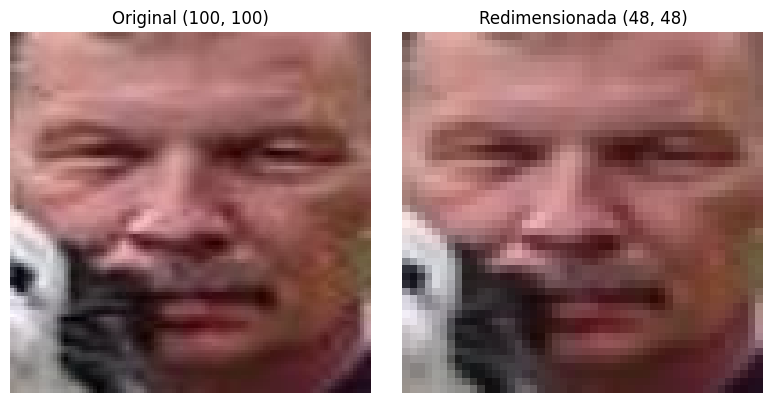

In [4]:
# --- Redimensionamiento ---

if APLICAR_REDIMENSIONAMIENTO:
    _resize = transforms.Resize(TAMANO_IMAGEN)
    transforms_train.append(_resize)
    transforms_val.append(_resize)
    print(f"Redimensionamiento activo → {TAMANO_IMAGEN}")
else:
    print("Redimensionamiento desactivado")

# Vista previa: comparar original vs redimensionada
if APLICAR_REDIMENSIONAMIENTO:
    muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.jpg"), None)
    if muestra is None:
        muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.png"), None)

    if muestra is not None:
        img_original = Image.open(muestra)
        img_redimensionada = _resize(img_original)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_original)
        axes[0].set_title(f"Original {img_original.size}")
        axes[0].axis("off")
        axes[1].imshow(img_redimensionada)
        axes[1].set_title(f"Redimensionada {img_redimensionada.size}")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontró imagen de ejemplo en el dataset de entrenamiento.")

### 1.4 Escala de grises

Convierte las imágenes a un solo canal. Reduce dimensionalidad y enfoca el modelo en forma y contraste. Se usa `torchvision.transforms.Grayscale`.

Escala de grises activa → 1 canal


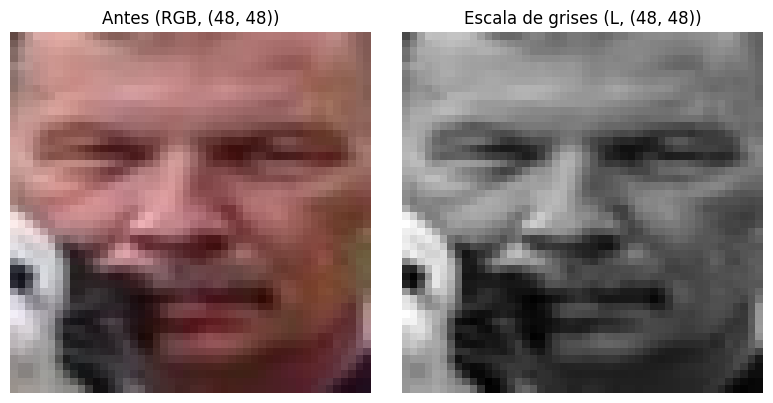

In [5]:
# --- Escala de grises ---

if APLICAR_ESCALA_DE_GRISES:
    _grayscale = transforms.Grayscale(num_output_channels=1)
    transforms_train.append(_grayscale)
    transforms_val.append(_grayscale)
    print("Escala de grises activa → 1 canal")
else:
    print("Escala de grises desactivada")

# Vista previa: comparar antes vs después de convertir a escala de grises
if APLICAR_ESCALA_DE_GRISES:
    muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.jpg"), None)
    if muestra is None:
        muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.png"), None)

    if muestra is not None:
        img_original = Image.open(muestra)
        _pipeline_previo = transforms.Compose(transforms_train[:-1]) if len(transforms_train) > 1 else None
        img_antes = _pipeline_previo(img_original) if _pipeline_previo else img_original
        img_gris = _grayscale(img_antes)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_antes, cmap="gray" if img_antes.mode == "L" else None)
        axes[0].set_title(f"Antes ({img_antes.mode}, {img_antes.size})")
        axes[0].axis("off")
        axes[1].imshow(img_gris, cmap="gray")
        axes[1].set_title(f"Escala de grises ({img_gris.mode}, {img_gris.size})")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontró imagen de ejemplo en el dataset de entrenamiento.")

### 1.5 Normalización

Convierte la imagen a tensor en rango [0, 1] con `ToTensor` y luego escala con `Normalize` usando media y desviación estándar. Con `mean=[0.5]` y `std=[0.5]` los valores quedan aproximadamente en [-1, 1].

Normalización activa → mean=[0.5], std=[0.5]


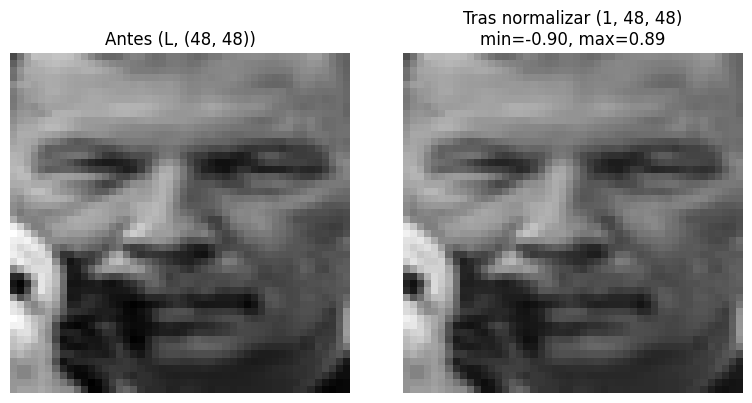

In [6]:
# --- Normalización ---

if APLICAR_NORMALIZACION:
    _to_tensor = transforms.ToTensor()
    _normalize = transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
    transforms_train.extend([_to_tensor, _normalize])
    transforms_val.extend([_to_tensor, _normalize])
    print(f"Normalización activa → mean={NORMALIZE_MEAN}, std={NORMALIZE_STD}")
else:
    print("Normalización desactivada")

# Vista previa: imagen antes vs tensor normalizado
if APLICAR_NORMALIZACION:
    muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.jpg"), None)
    if muestra is None:
        muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.png"), None)

    if muestra is not None:
        img_original = Image.open(muestra)
        _pipeline_previo = transforms.Compose(transforms_train[:-2]) if len(transforms_train) > 2 else None
        img_antes = _pipeline_previo(img_original) if _pipeline_previo else img_original
        tensor_norm = _normalize(_to_tensor(img_antes))

        def _desnormalizar(tensor):
            t = tensor.clone()
            for c in range(t.shape[0]):
                t[c] = t[c] * NORMALIZE_STD[c] + NORMALIZE_MEAN[c]
            return t

        img_restaurada = _desnormalizar(tensor_norm)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_antes, cmap="gray" if img_antes.mode == "L" else None)
        axes[0].set_title(f"Antes ({img_antes.mode}, {img_antes.size})")
        axes[0].axis("off")

        if img_restaurada.shape[0] == 1:
            axes[1].imshow(img_restaurada.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
        else:
            axes[1].imshow(img_restaurada.permute(1, 2, 0).numpy(), vmin=0, vmax=1)
        axes[1].set_title(
            f"Tras normalizar {tuple(tensor_norm.shape)}\n"
            f"min={tensor_norm.min():.2f}, max={tensor_norm.max():.2f}"
        )
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontró imagen de ejemplo en el dataset de entrenamiento.")

### 1.6 Aumento de datos

Genera variaciones aleatorias **solo en entrenamiento** para mejorar la generalización. Las transformaciones se insertan antes de `ToTensor` y `Normalize`. Se controlan de forma independiente con las variables `APLICAR_*` de la celda de configuración.

Aumento de datos activo (solo transforms_train):
  - RandomHorizontalFlip


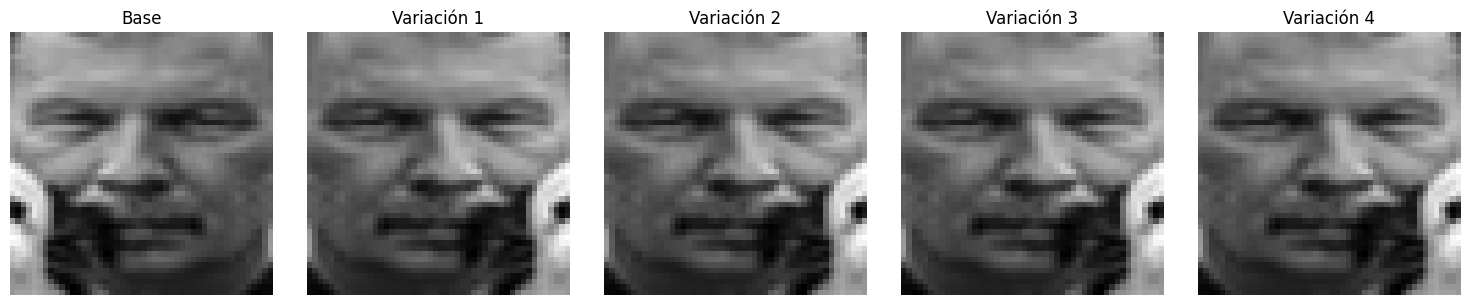

In [7]:
# --- Aumento de datos ---

_augmentaciones = []
_mensajes = []

if APLICAR_VOLTEO_HORIZONTAL:
    _augmentaciones.append(transforms.RandomHorizontalFlip())
    _mensajes.append("RandomHorizontalFlip")

if APLICAR_ROTACION:
    _augmentaciones.append(transforms.RandomRotation(ROTACION_GRADOS))
    _mensajes.append(f"RandomRotation({ROTACION_GRADOS}°)")

if APLICAR_RECORTE_ALEATORIO:
    _augmentaciones.append(transforms.RandomCrop(RECORTE_TAMANO))
    _mensajes.append(f"RandomCrop{RECORTE_TAMANO}")

if APLICAR_COLOR_JITTER:
    _augmentaciones.append(transforms.ColorJitter(
        brightness=COLOR_JITTER_BRIGHTNESS,
        contrast=COLOR_JITTER_CONTRAST,
    ))
    _mensajes.append("ColorJitter")

if _augmentaciones:
    _idx_insercion = next(
        (i for i, t in enumerate(transforms_train) if isinstance(t, transforms.ToTensor)),
        len(transforms_train),
    )
    for i, aug in enumerate(_augmentaciones):
        transforms_train.insert(_idx_insercion + i, aug)
    print("Aumento de datos activo (solo transforms_train):")
    for msg in _mensajes:
        print(f"  - {msg}")
else:
    print("Aumento de datos desactivado")

# Vista previa: imagen base vs variaciones aleatorias
if _augmentaciones:
    muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.jpg"), None)
    if muestra is None:
        muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.png"), None)

    if muestra is not None:
        img_original = Image.open(muestra)
        _pipeline_base = transforms.Compose(transforms_train[:_idx_insercion])
        _pipeline_aug = transforms.Compose(transforms_train[:_idx_insercion] + _augmentaciones)
        img_base = _pipeline_base(img_original)

        n_variaciones = 4
        fig, axes = plt.subplots(1, n_variaciones + 1, figsize=(3 * (n_variaciones + 1), 3))
        axes[0].imshow(img_base, cmap="gray" if img_base.mode == "L" else None)
        axes[0].set_title("Base")
        axes[0].axis("off")

        for i in range(n_variaciones):
            img_aug = _pipeline_aug(img_original)
            axes[i + 1].imshow(img_aug, cmap="gray" if img_aug.mode == "L" else None)
            axes[i + 1].set_title(f"Variación {i + 1}")
            axes[i + 1].axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("No se encontró imagen de ejemplo en el dataset de entrenamiento.")

### 1.7 Balanceo de datos

Si las clases están desbalanceadas, se puede compensar en el entrenamiento con **oversampling** mediante `WeightedRandomSampler` de PyTorch. No es una transformación de imagen: define cómo se eligen las muestras en el `DataLoader` de entrenamiento.

Balanceo activo → WeightedRandomSampler (oversampling de clases minoritarias)
Conteo por clase en entrenamiento:
  - alegria: 4772
  - disgusto: 717
  - enojo: 705
  - miedo: 281
  - seriedad: 2524
  - sorpresa: 1290
  - tristeza: 1982


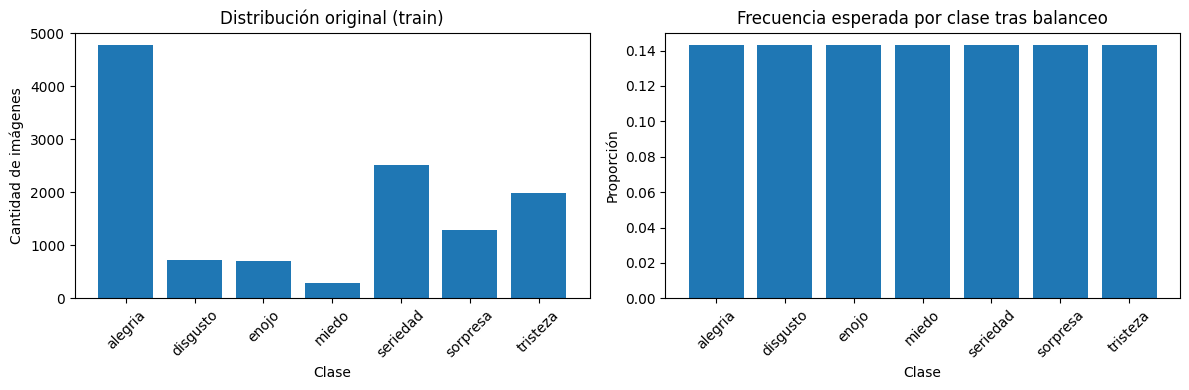

In [8]:
# --- Balanceo de datos ---

train_sampler = None


def _contar_imagenes(carpeta):
    total = 0
    for extension in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
        total += len(list(carpeta.glob(extension)))
    return total


if APLICAR_BALANCEO:
    clases = sorted(p.name for p in Path(DATASET_ROOT_TRAIN).iterdir() if p.is_dir())
    conteo_por_clase = {clase: _contar_imagenes(Path(DATASET_ROOT_TRAIN) / clase) for clase in clases}

    pesos_por_clase = {clase: 1.0 / conteo for clase, conteo in conteo_por_clase.items() if conteo > 0}
    pesos_muestra = []

    for clase in clases:
        peso = pesos_por_clase.get(clase)
        if peso is None:
            continue
        carpeta_clase = Path(DATASET_ROOT_TRAIN) / clase
        for extension in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
            for _ in carpeta_clase.glob(extension):
                pesos_muestra.append(peso)

    if pesos_muestra:
        train_sampler = WeightedRandomSampler(
            weights=pesos_muestra,
            num_samples=len(pesos_muestra),
            replacement=True,
        )
        print("Balanceo activo → WeightedRandomSampler (oversampling de clases minoritarias)")
        print("Conteo por clase en entrenamiento:")
        for clase in clases:
            print(f"  - {clase}: {conteo_por_clase[clase]}")
    else:
        print("Balanceo desactivado: no se encontraron imágenes en el dataset de entrenamiento.")
else:
    print("Balanceo desactivado")

# Vista previa: distribución original vs frecuencia esperada tras balanceo
if APLICAR_BALANCEO and pesos_muestra:
    frecuencia_esperada = {clase: pesos_por_clase[clase] * conteo_por_clase[clase] for clase in clases if conteo_por_clase[clase] > 0}
    total_esperado = sum(frecuencia_esperada.values())
    frecuencia_esperada = {clase: valor / total_esperado for clase, valor in frecuencia_esperada.items()}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(conteo_por_clase.keys(), conteo_por_clase.values())
    axes[0].set_title("Distribución original (train)")
    axes[0].set_xlabel("Clase")
    axes[0].set_ylabel("Cantidad de imágenes")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(frecuencia_esperada.keys(), frecuencia_esperada.values())
    axes[1].set_title("Frecuencia esperada por clase tras balanceo")
    axes[1].set_xlabel("Clase")
    axes[1].set_ylabel("Proporción")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

## 2- Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

### 2.1 Arquitectura CNN recomendada

Propuesta para imágenes **48×48 en escala de grises** (1 canal) y **7 clases** de emoción, construida desde cero con PyTorch.

#### Diseño general

| Bloque | Capas | Salida espacial |
|---|---|---|
| Entrada | — | 1 × 48 × 48 |
| Conv 1 | Conv2d → BatchNorm → ReLU → MaxPool(2) | 32 × 24 × 24 |
| Conv 2 | Conv2d → BatchNorm → ReLU → MaxPool(2) | 64 × 12 × 12 |
| Conv 3 | Conv2d → BatchNorm → ReLU → MaxPool(2) | 128 × 6 × 6 |
| Clasificador | Flatten → Linear → ReLU → Dropout → Linear | 7 logits |

**Parámetros convolucionales:**
- **3 bloques convolucionales** con filtros crecientes (32 → 64 → 128): suficiente profundidad para capturar bordes, texturas y patrones faciales en imágenes pequeñas, sin hacer la red tan grande que sobreajuste fácilmente.
- **Kernels 3×3** con `padding=1`: tamaño estándar para detectar patrones locales (ojos, boca, arrugas); mantiene dimensiones antes del pooling y usa menos parámetros que kernels 5×5.
- **MaxPooling 2×2**: reduce la resolución espacial, aporta invarianza a pequeños desplazamientos y disminuye el costo computacional.
- **BatchNorm** después de cada convolución: estabiliza el entrenamiento y permite usar learning rates un poco más altos.

**Capas fully connected:**
- **Linear(4608 → 256)**: condensa las características extraídas.
- **Dropout(0.5)**: regulariza y reduce overfitting.
- **Linear(256 → 7)**: capa de salida (una unidad por emoción).

#### Funciones de activación

| Capa | Activación | Justificación |
|---|---|---|
| Convolucionales | **ReLU** | Evita el desvanecimiento del gradiente, es computacionalmente eficiente y produce activaciones dispersas, útil para detectar rasgos presentes/ausentes. |
| Fully connected oculta | **ReLU** | Misma razón; mantiene coherencia en toda la red. |
| Salida | **Sin activación (logits)** | `CrossEntropyLoss` ya aplica softmax internamente; aplicar softmax antes duplicaría la operación y puede empeorar la estabilidad numérica. |

#### Función de costo, optimizador y learning rate

| Hiperparámetro | Valor recomendado | Justificación |
|---|---|---|
| **Función de costo** | `CrossEntropyLoss` | Clasificación multiclase mutuamente excluyente (cada imagen tiene una sola emoción). |
| **Optimizador** | **Adam** (`lr=1e-3`) | Adapta el learning rate por parámetro; converge bien en CNNs pequeñas sin ajuste fino extenso. Alternativa válida: SGD con momentum (`lr=1e-2`, `momentum=0.9`). |
| **Learning rate** | **0.001** | Punto de partida habitual para Adam en redes entrenadas desde cero. Si la loss oscila, bajar a `3e-4`; si converge muy lento, probar `3e-3`. |
| **Batch size** | **32 o 64** | Balance entre estabilidad del gradiente y uso de memoria en Colab. |
| **Épocas** | **30–50** | Con early stopping o monitoreo de validación para evitar overfitting. |

Esta arquitectura es un punto de partida razonable para el dataset de emociones faciales. Los hiperparámetros pueden ajustarse según los resultados de validación.

In [9]:
import torch.nn as nn

# --- Configuración de arquitectura ---
NUM_CANALES_ENTRADA = 1 if APLICAR_ESCALA_DE_GRISES else 3
NUM_CLASES = len([p for p in Path(DATASET_ROOT_TRAIN).iterdir() if p.is_dir()])

FILTROS_CONV = [32, 64, 128]
TAMANO_KERNEL = 3
PADDING_CONV = 1
TAMANO_POOL = 2
UNIDADES_FC_OCULTAS = 256
DROPOUT_FC = 0.5

# --- Configuración de entrenamiento ---
BATCH_SIZE = 32
NUM_EPOCHS = 40
#LEARNING_RATE = 1e-3
LEARNING_RATE = 1e-4
OPTIMIZADOR = "adam"  # "adam" o "sgd"
SGD_MOMENTUM = 0.9

# --- Early Stopping ---
APLICAR_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 5          # épocas sin mejora antes de detener
EARLY_STOPPING_MIN_DELTA = 0.0       # mejora mínima requerida para resetear el contador
EARLY_STOPPING_METRICA = "val_loss"  # "val_loss", "val_acc" o "val_f1"
EARLY_STOPPING_RESTAURAR_MEJOR_MODELO = True  # cargar los pesos de la mejor época al finalizar


def _crear_bloque_conv(canales_entrada, canales_salida):
    return nn.Sequential(
        nn.Conv2d(canales_entrada, canales_salida, TAMANO_KERNEL, padding=PADDING_CONV),
        nn.BatchNorm2d(canales_salida),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(TAMANO_POOL),
    )


class EmotionCNN(nn.Module):
    """CNN desde cero para clasificación de emociones (sin modelos pre-entrenados)."""

    def __init__(
        self,
        num_canales=NUM_CANALES_ENTRADA,
        num_clases=NUM_CLASES,
        filtros=FILTROS_CONV,
        unidades_fc=UNIDADES_FC_OCULTAS,
        dropout=DROPOUT_FC,
    ):
        super().__init__()

        bloques = []
        canales_previos = num_canales
        for filtros_salida in filtros:
            bloques.append(_crear_bloque_conv(canales_previos, filtros_salida))
            canales_previos = filtros_salida
        self.features = nn.Sequential(*bloques)

        with torch.no_grad():
            muestra = torch.zeros(1, num_canales, TAMANO_IMAGEN[0], TAMANO_IMAGEN[1])
            tamano_flat = self.features(muestra).view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Linear(tamano_flat, unidades_fc),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(unidades_fc, num_clases),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


# Pipelines finales de preprocesamiento
transform_train = transforms.Compose(transforms_train)
transform_val = transforms.Compose(transforms_val)

# Modelo, función de costo y optimizador
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionCNN().to(device)
criterion = nn.CrossEntropyLoss()

if OPTIMIZADOR.lower() == "adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZADOR.lower() == "sgd":
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=SGD_MOMENTUM)
else:
    raise ValueError("OPTIMIZADOR debe ser 'adam' o 'sgd'")

parametros_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Dispositivo: {device}")
print(f"Entrada: {NUM_CANALES_ENTRADA} canal(es) | Clases: {NUM_CLASES}")
print(f"Filtros conv: {FILTROS_CONV} | Kernel: {TAMANO_KERNEL}x{TAMANO_KERNEL} | FC oculta: {UNIDADES_FC_OCULTAS}")
print(f"Loss: CrossEntropyLoss | Optimizador: {OPTIMIZADOR.upper()} | LR: {LEARNING_RATE}")
print(f"Parámetros entrenables: {parametros_entrenables:,}")
print(model)

Dispositivo: cpu
Entrada: 1 canal(es) | Clases: 7
Filtros conv: [32, 64, 128] | Kernel: 3x3 | FC oculta: 256
Loss: CrossEntropyLoss | Optimizador: ADAM | LR: 0.0001
Parámetros entrenables: 1,274,823
EmotionCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2

## 3- Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


### 3.0 Entrenamiento modelo

In [10]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

try:
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
except ModuleNotFoundError:
    _pip_install("scikit-learn")
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


# --- Datasets y DataLoaders ---
dataset_train = ImageFolder(DATASET_ROOT_TRAIN, transform=transform_train)
dataset_val = ImageFolder(DATASET_ROOT_VAL, transform=transform_val)
class_names = dataset_train.classes

train_loader = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=(train_sampler is None),
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

print(f"Train: {len(dataset_train)} imágenes | Val: {len(dataset_val)} imágenes")
print(f"Clases: {class_names}")


def _entrenar_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_total = 0.0
    etiquetas_todas = []
    predicciones_todas = []

    for imagenes, etiquetas in loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        optimizer.zero_grad()
        salidas = model(imagenes)
        loss = criterion(salidas, etiquetas)
        loss.backward()
        optimizer.step()

        loss_total += loss.item() * imagenes.size(0)
        predicciones_todas.extend(salidas.argmax(dim=1).cpu().numpy())
        etiquetas_todas.extend(etiquetas.cpu().numpy())

    loss_promedio = loss_total / len(loader.dataset)
    accuracy = accuracy_score(etiquetas_todas, predicciones_todas)
    f1_macro = f1_score(etiquetas_todas, predicciones_todas, average="macro", zero_division=0)
    return loss_promedio, accuracy, f1_macro


@torch.no_grad()
def _evaluar_epoch(model, loader, criterion, device):
    model.eval()
    loss_total = 0.0
    etiquetas_todas = []
    predicciones_todas = []

    for imagenes, etiquetas in loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        salidas = model(imagenes)
        loss = criterion(salidas, etiquetas)

        loss_total += loss.item() * imagenes.size(0)
        predicciones_todas.extend(salidas.argmax(dim=1).cpu().numpy())
        etiquetas_todas.extend(etiquetas.cpu().numpy())

    loss_promedio = loss_total / len(loader.dataset)
    accuracy = accuracy_score(etiquetas_todas, predicciones_todas)
    f1_macro = f1_score(etiquetas_todas, predicciones_todas, average="macro", zero_division=0)
    return loss_promedio, accuracy, f1_macro, etiquetas_todas, predicciones_todas


def _early_stopping_mejoro(valor_actual, mejor_valor, modo, min_delta):
    if mejor_valor is None:
        return True
    if modo == "min":
        return valor_actual < mejor_valor - min_delta
    return valor_actual > mejor_valor + min_delta


_metricas_early_stopping = {
    "val_loss": "min",
    "val_acc": "max",
    "val_f1": "max",
}
if EARLY_STOPPING_METRICA not in _metricas_early_stopping:
    raise ValueError(
        f"EARLY_STOPPING_METRICA debe ser uno de {list(_metricas_early_stopping)}"
    )
_early_stopping_modo = _metricas_early_stopping[EARLY_STOPPING_METRICA]


# --- Entrenamiento ---
historial_entrenamiento = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
}

mejor_valor = None
mejor_epoca = 0
epochs_sin_mejora = 0
mejor_state = None
detenido_por_early_stopping = False

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, train_f1 = _entrenar_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, y_val_true, y_val_pred = _evaluar_epoch(model, val_loader, criterion, device)

    historial_entrenamiento["train_loss"].append(train_loss)
    historial_entrenamiento["val_loss"].append(val_loss)
    historial_entrenamiento["train_acc"].append(train_acc)
    historial_entrenamiento["val_acc"].append(val_acc)
    historial_entrenamiento["train_f1"].append(train_f1)
    historial_entrenamiento["val_f1"].append(val_f1)

    metricas_epoca = {
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
    }
    metrica_actual = metricas_epoca[EARLY_STOPPING_METRICA]

    msg_epoca = (
        f"Época {epoch:02d}/{NUM_EPOCHS} | "
        f"loss: {train_loss:.4f}/{val_loss:.4f} | "
        f"acc: {train_acc:.4f}/{val_acc:.4f} | "
        f"f1: {train_f1:.4f}/{val_f1:.4f}"
    )

    if _early_stopping_mejoro(metrica_actual, mejor_valor, _early_stopping_modo, EARLY_STOPPING_MIN_DELTA):
        mejor_valor = metrica_actual
        mejor_epoca = epoch
        epochs_sin_mejora = 0
        if EARLY_STOPPING_RESTAURAR_MEJOR_MODELO:
            mejor_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        msg_epoca += f" | * mejor {EARLY_STOPPING_METRICA}: {metrica_actual:.4f}"
    elif APLICAR_EARLY_STOPPING:
        epochs_sin_mejora += 1
        msg_epoca += f" | sin mejora: {epochs_sin_mejora}/{EARLY_STOPPING_PATIENCE}"

    print(msg_epoca)

    if APLICAR_EARLY_STOPPING and epochs_sin_mejora >= EARLY_STOPPING_PATIENCE:
        detenido_por_early_stopping = True
        print(
            f"\nEarly stopping: entrenamiento detenido en época {epoch} "
            f"(sin mejora en {EARLY_STOPPING_PATIENCE} épocas consecutivas)"
        )
        break

if EARLY_STOPPING_RESTAURAR_MEJOR_MODELO and mejor_state is not None:
    model.load_state_dict(mejor_state)
    print(
        f"\nModelo restaurado a la mejor época ({mejor_epoca}) "
        f"según {EARLY_STOPPING_METRICA}: {mejor_valor:.4f}"
    )
    val_loss_final, val_acc_final, val_f1_final, y_val_true, y_val_pred = _evaluar_epoch(
        model, val_loader, criterion, device
    )
elif detenido_por_early_stopping:
    print(
        f"\nMejor época registrada: {mejor_epoca} "
        f"({EARLY_STOPPING_METRICA}: {mejor_valor:.4f})"
    )
    val_loss_final = historial_entrenamiento["val_loss"][-1]
    val_acc_final = historial_entrenamiento["val_acc"][-1]
    val_f1_final = historial_entrenamiento["val_f1"][-1]
else:
    val_loss_final = historial_entrenamiento["val_loss"][-1]
    val_acc_final = historial_entrenamiento["val_acc"][-1]
    val_f1_final = historial_entrenamiento["val_f1"][-1]

metricas_val_final = {
    "val_loss": val_loss_final,
    "val_acc": val_acc_final,
    "val_f1": val_f1_final,
    "mejor_epoca": mejor_epoca,
    "detenido_por_early_stopping": detenido_por_early_stopping,
}

# Métricas finales en validación (mejor modelo o última época)
print("\n--- Métricas finales en validación ---")
print(f"Accuracy: {val_acc_final:.4f}")
print(f"F1 macro: {val_f1_final:.4f}")
print(f"Loss: {val_loss_final:.4f}")
if mejor_epoca > 0:
    print(f"Mejor época: {mejor_epoca} | Early stopping: {'sí' if detenido_por_early_stopping else 'no'}")

print("\nClassification report:")
print(classification_report(y_val_true, y_val_pred, target_names=class_names, zero_division=0))

print("Matriz de confusión (absoluta):")
print(confusion_matrix(y_val_true, y_val_pred))

matriz_confusion_norm = confusion_matrix(y_val_true, y_val_pred, normalize="true")
print("\nMatriz de confusión (normalizada por fila):")
print(np.round(matriz_confusion_norm, 3))

# Guardado para gráficos y evaluación posterior
etiquetas_val_final = y_val_true
predicciones_val_final = y_val_pred
matriz_confusion_final = confusion_matrix(y_val_true, y_val_pred)
matriz_confusion_norm_final = matriz_confusion_norm

Train: 12271 imágenes | Val: 3068 imágenes
Clases: ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
Época 01/40 | loss: 1.6587/1.4548 | acc: 0.3613/0.4700 | f1: 0.3551/0.3803 | * mejor val_loss: 1.4548
Época 02/40 | loss: 1.2948/1.0917 | acc: 0.5268/0.6297 | f1: 0.5213/0.5313 | * mejor val_loss: 1.0917
Época 03/40 | loss: 1.1336/1.0644 | acc: 0.5834/0.6271 | f1: 0.5800/0.5485 | * mejor val_loss: 1.0644
Época 04/40 | loss: 1.0222/0.9140 | acc: 0.6281/0.6799 | f1: 0.6270/0.5833 | * mejor val_loss: 0.9140
Época 05/40 | loss: 0.9394/0.9929 | acc: 0.6655/0.6444 | f1: 0.6640/0.5730 | sin mejora: 1/5
Época 06/40 | loss: 0.8589/0.8327 | acc: 0.6905/0.7053 | f1: 0.6912/0.5918 | * mejor val_loss: 0.8327
Época 07/40 | loss: 0.7998/0.8331 | acc: 0.7173/0.7099 | f1: 0.7154/0.6002 | sin mejora: 1/5
Época 08/40 | loss: 0.7256/0.7845 | acc: 0.7474/0.7223 | f1: 0.7471/0.6221 | * mejor val_loss: 0.7845
Época 09/40 | loss: 0.6754/0.8259 | acc: 0.7575/0.6995 | f1: 0.7576/0.620

### 3.1 Accuracy

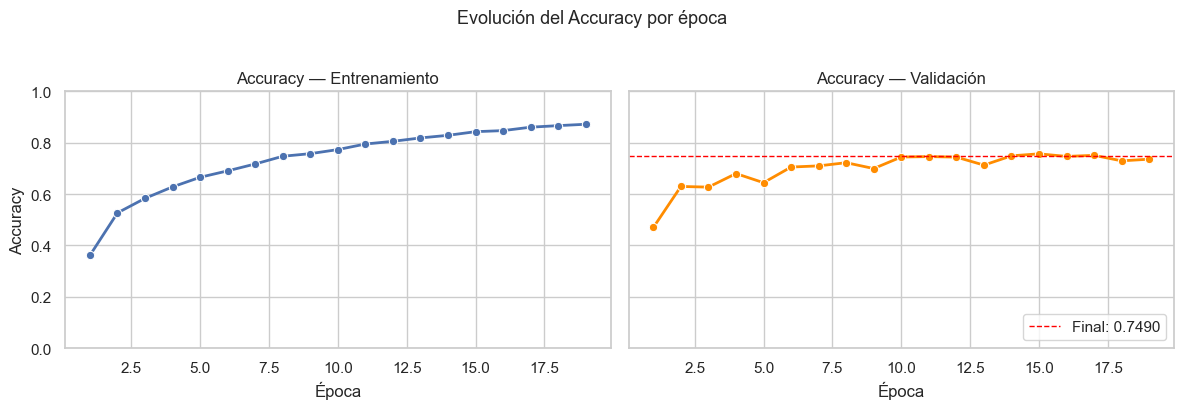

Accuracy final en validación: 0.7490 (74.90%)


In [11]:
try:
    import seaborn as sns
except ModuleNotFoundError:
    _pip_install("seaborn")
    import seaborn as sns

sns.set_theme(style="whitegrid")

accuracy_final_val = metricas_val_final["val_acc"]
epocas = list(range(1, len(historial_entrenamiento["train_acc"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(x=epocas, y=historial_entrenamiento["train_acc"], ax=axes[0], marker="o", linewidth=2)
axes[0].set_title("Accuracy — Entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

sns.lineplot(x=epocas, y=historial_entrenamiento["val_acc"], ax=axes[1], marker="o", linewidth=2, color="darkorange")
axes[1].set_title("Accuracy — Validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].axhline(accuracy_final_val, color="red", linestyle="--", linewidth=1, label=f"Final: {accuracy_final_val:.4f}")
axes[1].legend(loc="lower right")

fig.suptitle("Evolución del Accuracy por época", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Accuracy final en validación: {accuracy_final_val:.4f} ({accuracy_final_val * 100:.2f}%)")

### 3.2 F1 Macro

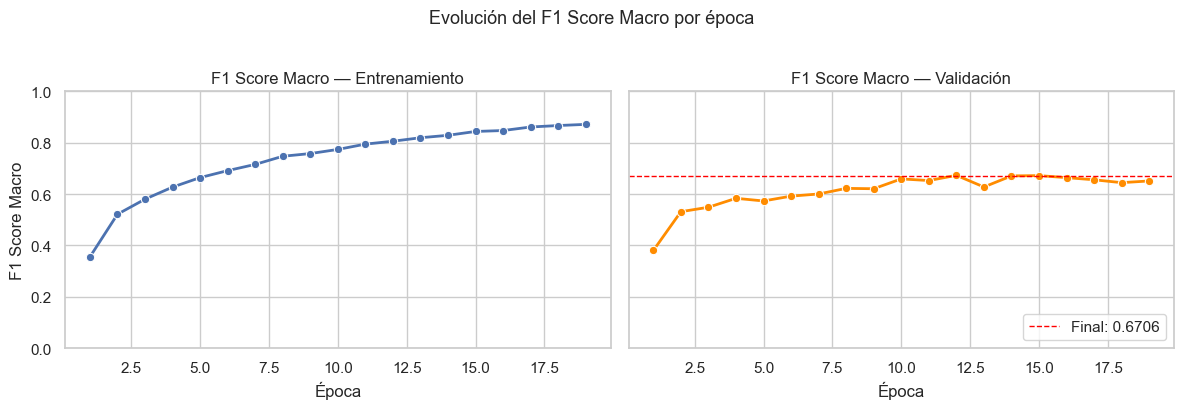

F1 Score Macro final en validación: 0.6706 (67.06%)


In [12]:
f1_final_val = metricas_val_final["val_f1"]
epocas = list(range(1, len(historial_entrenamiento["train_f1"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(x=epocas, y=historial_entrenamiento["train_f1"], ax=axes[0], marker="o", linewidth=2)
axes[0].set_title("F1 Score Macro — Entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("F1 Score Macro")
axes[0].set_ylim(0, 1)

sns.lineplot(x=epocas, y=historial_entrenamiento["val_f1"], ax=axes[1], marker="o", linewidth=2, color="darkorange")
axes[1].set_title("F1 Score Macro — Validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 Score Macro")
axes[1].set_ylim(0, 1)
axes[1].axhline(f1_final_val, color="red", linestyle="--", linewidth=1, label=f"Final: {f1_final_val:.4f}")
axes[1].legend(loc="lower right")

fig.suptitle("Evolución del F1 Score Macro por época", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"F1 Score Macro final en validación: {f1_final_val:.4f} ({f1_final_val * 100:.2f}%)")

### 3.3 Costo (Loss)

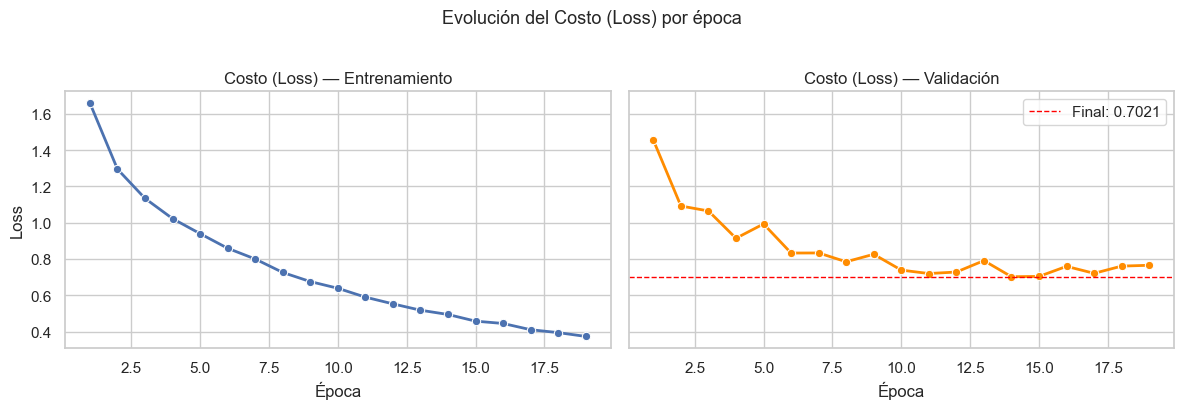

Costo (Loss) final en validación: 0.7021


In [13]:
loss_final_val = metricas_val_final["val_loss"]
epocas = list(range(1, len(historial_entrenamiento["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(x=epocas, y=historial_entrenamiento["train_loss"], ax=axes[0], marker="o", linewidth=2)
axes[0].set_title("Costo (Loss) — Entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")

sns.lineplot(x=epocas, y=historial_entrenamiento["val_loss"], ax=axes[1], marker="o", linewidth=2, color="darkorange")
axes[1].set_title("Costo (Loss) — Validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].axhline(loss_final_val, color="red", linestyle="--", linewidth=1, label=f"Final: {loss_final_val:.4f}")
axes[1].legend(loc="upper right")

fig.suptitle("Evolución del Costo (Loss) por época", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Costo (Loss) final en validación: {loss_final_val:.4f}")

### 3.4 Classification report

In [14]:
try:
    from sklearn.metrics import classification_report
except ModuleNotFoundError:
    _pip_install("scikit-learn")
    from sklearn.metrics import classification_report

print("Classification report — validación (última época)\n")
print(
    classification_report(
        etiquetas_val_final,
        predicciones_val_final,
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

Classification report — validación (última época)

              precision    recall  f1-score   support

     alegria     0.9169    0.8194    0.8654      1185
    disgusto     0.4444    0.5000    0.4706       160
       enojo     0.6010    0.7346    0.6611       162
       miedo     0.6364    0.4730    0.5426        74
    seriedad     0.7293    0.7132    0.7212       680
    sorpresa     0.7399    0.7781    0.7585       329
    tristeza     0.6230    0.7364    0.6750       478

    accuracy                         0.7490      3068
   macro avg     0.6701    0.6792    0.6706      3068
weighted avg     0.7625    0.7490    0.7532      3068



### 3.5 Matrices de confusión.

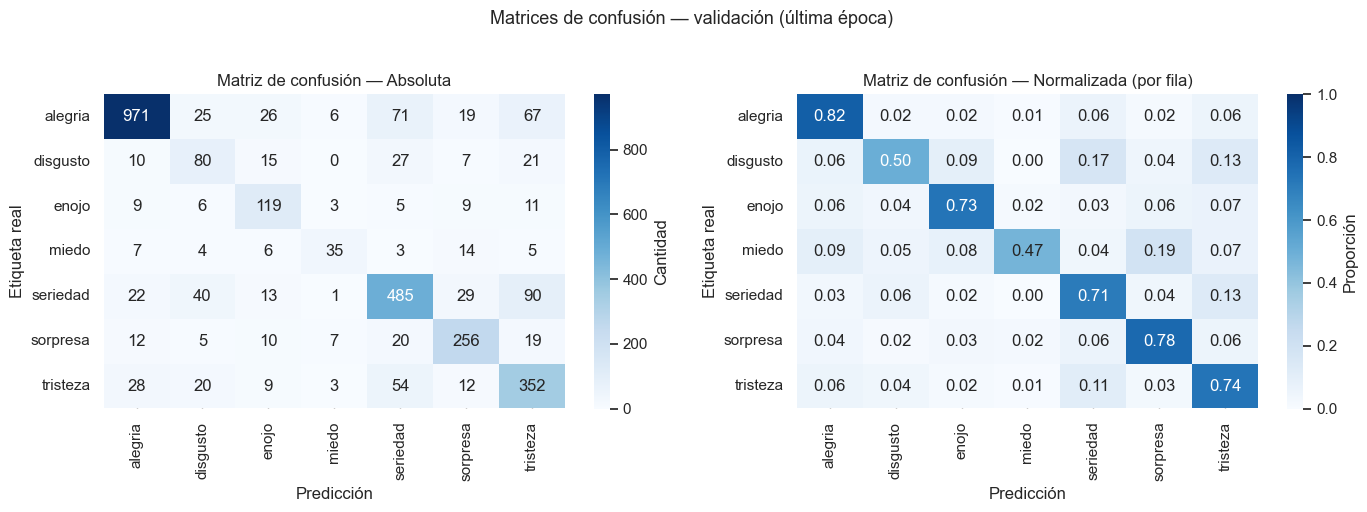

In [15]:
try:
    from sklearn.metrics import confusion_matrix
except ModuleNotFoundError:
    _pip_install("scikit-learn")
    from sklearn.metrics import confusion_matrix

try:
    import seaborn as sns
except ModuleNotFoundError:
    _pip_install("seaborn")
    import seaborn as sns

matriz_abs = confusion_matrix(etiquetas_val_final, predicciones_val_final)
matriz_norm = confusion_matrix(etiquetas_val_final, predicciones_val_final, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    matriz_abs,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    cbar_kws={"label": "Cantidad"},
)
axes[0].set_title("Matriz de confusión — Absoluta")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Etiqueta real")

sns.heatmap(
    matriz_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    cbar_kws={"label": "Proporción"},
)
axes[1].set_title("Matriz de confusión — Normalizada (por fila)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Etiqueta real")

fig.suptitle("Matrices de confusión — validación (última época)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 3.6 Comentarios del entrenamiento:

- Se probó sin balanceo de clases y daba sobreajuste
- Se activó el balanceo y mejoró mucho, pero quedaba un overfitting residual y mucho ruido
- Se disminuyó el learning rate y se redujo el ruido, pero sigue observandose un sobre ajuste.
- Se implementó Early Stopping: el entrenamiento se corta alrededor de la epoca 16. Efectivamente mejora el modelo y se refleja en la matriz de confusion normalizada ((real/prediccion) Antes disgusto/disgusto 0.23 y disgusto/seriedad 0.38 - Ahora disgusto/disgusto 0.37 y disgusto/seriedad 0.19 )

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

In [20]:
import io
import subprocess
import sys

EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
MIN_IMAGENES_PRUEBA = 12


def _seleccionar_imagenes_macos():
    """Diálogo nativo de macOS (evita crash de tkinter en Jupyter/Cursor)."""
    script = """
try
    set chosenFiles to choose file with prompt "Seleccionar al menos 12 imágenes (Cmd+clic para varias)" with multiple selections allowed
    set pathList to {}
    repeat with f in chosenFiles
        set end of pathList to POSIX path of f
    end repeat
    set AppleScript's text item delimiters to linefeed
    set outText to pathList as text
    set AppleScript's text item delimiters to ""
    return outText
on error number -128
    return ""
end try
"""
    result = subprocess.run(
        ["osascript", "-e", script],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0 and not result.stdout.strip():
        return []
    return [p for p in result.stdout.strip().splitlines() if p]


def _seleccionar_imagenes_ipywidgets():
    """Widget de carga para Jupyter cuando no hay diálogo nativo disponible."""
    try:
        import ipywidgets as widgets
        from IPython.display import clear_output, display
    except ModuleNotFoundError:
        _pip_install("ipywidgets")
        import ipywidgets as widgets
        from IPython.display import clear_output, display

    uploader = widgets.FileUpload(accept=".jpg,.jpeg,.png,.webp,.bmp", multiple=True)
    btn = widgets.Button(description="Continuar", button_style="success")
    estado = {"listo": False}

    def _continuar(_):
        estado["listo"] = True

    btn.on_click(_continuar)
    display(
        widgets.VBox([
            widgets.HTML(
                f"<b>Seleccioná al menos {MIN_IMAGENES_PRUEBA} imágenes y luego presioná <i>Continuar</i></b>"
            ),
            uploader,
            btn,
        ])
    )

    import time

    while not estado["listo"]:
        time.sleep(0.1)

    imagenes = []
    for item in uploader.value:
        nombre = item["name"]
        if Path(nombre).suffix.lower() not in EXTENSIONES_IMAGEN:
            print(f"Archivo omitido (no es imagen): {nombre}")
            continue
        imagenes.append((nombre, Image.open(io.BytesIO(item["content"])).copy()))

    clear_output(wait=True)
    return imagenes


def _seleccionar_imagenes_interactivo():
    """Abre un diálogo para elegir una o más imágenes (Colab o entorno local)."""
    imagenes = []

    if IN_COLAB:
        from google.colab import files

        print(f"Seleccioná al menos {MIN_IMAGENES_PRUEBA} imágenes en el diálogo de carga...")
        subidas = files.upload()
        for nombre, contenido in subidas.items():
            if Path(nombre).suffix.lower() not in EXTENSIONES_IMAGEN:
                print(f"Archivo omitido (no es imagen): {nombre}")
                continue
            imagenes.append((nombre, Image.open(io.BytesIO(contenido)).copy()))
    elif sys.platform == "darwin":
        print(f"Seleccioná al menos {MIN_IMAGENES_PRUEBA} imágenes en el diálogo del sistema...")
        rutas = _seleccionar_imagenes_macos()
        for ruta in rutas:
            p = Path(ruta)
            if p.suffix.lower() not in EXTENSIONES_IMAGEN:
                print(f"Archivo omitido (no es imagen): {p.name}")
                continue
            with Image.open(p) as img:
                imagenes.append((p.name, img.copy()))
    else:
        print("Usá el widget para cargar imágenes...")
        return _seleccionar_imagenes_ipywidgets()

    return imagenes


def _preguntar_reintentar():
    while True:
        respuesta = input("¿Desea reintentar? [Y/N]: ").strip().upper()
        if respuesta == "Y":
            return True
        if respuesta == "N":
            return False
        print("Respuesta no válida. Ingresá Y para reintentar o N para cancelar.")


def _cargar_imagenes_prueba():
    """Solicita imágenes hasta alcanzar el mínimo requerido o hasta que el usuario cancele."""
    while True:
        imagenes = _seleccionar_imagenes_interactivo()
        cantidad = len(imagenes)

        if cantidad >= MIN_IMAGENES_PRUEBA:
            return imagenes

        if cantidad == 0:
            print(
                f"No se seleccionaron imágenes. "
                f"Deben cargarse al menos {MIN_IMAGENES_PRUEBA} imágenes."
            )
        else:
            print(
                f"Se seleccionaron {cantidad} imágenes. "
                f"Deben cargarse al menos {MIN_IMAGENES_PRUEBA} imágenes."
            )

        if not _preguntar_reintentar():
            return None


def _tensor_a_imagen_display(tensor):
    t = tensor.detach().cpu().clone()
    if APLICAR_NORMALIZACION:
        for c in range(t.shape[0]):
            t[c] = t[c] * NORMALIZE_STD[c] + NORMALIZE_MEAN[c]
    t = t.clamp(0, 1)
    if t.shape[0] == 1:
        return t.squeeze(0).numpy(), "gray"
    return t.permute(1, 2, 0).numpy(), None


@torch.no_grad()
def _inferir_imagen(img_pil):
    model.eval()
    tensor = transform_val(img_pil).unsqueeze(0).to(device)
    logits = model(tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    clase_idx = int(probs.argmax())
    return tensor.squeeze(0), probs, clase_idx


imagenes_prueba = _cargar_imagenes_prueba()

if imagenes_prueba is None:
    print("Carga de imágenes cancelada por el usuario.")
else:
    print(f"Imágenes a evaluar: {len(imagenes_prueba)}")

    for nombre, img_original in imagenes_prueba:
        img_rgb = img_original.convert("RGB")

        tensor_proc, probs, clase_idx = _inferir_imagen(img_rgb)
        img_proc, cmap_proc = _tensor_a_imagen_display(tensor_proc)
        clase_predicha = class_names[clase_idx]

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].imshow(img_original)
        axes[0].set_title(f"Original\n{nombre}")
        axes[0].axis("off")

        axes[1].imshow(img_proc, cmap=cmap_proc, vmin=0, vmax=1)
        axes[1].set_title("Pre-procesada\n(mismo pipeline que validación)")
        axes[1].axis("off")

        axes[2].barh(class_names, probs, color="steelblue")
        axes[2].set_xlim(0, 1)
        axes[2].set_xlabel("Score (probabilidad)")
        axes[2].set_title(
            f"Clase inferida: {clase_predicha}\n"
            f"Confianza: {probs[clase_idx] * 100:.1f}%"
        )
        axes[2].invert_yaxis()
        for i, p in enumerate(probs):
            axes[2].text(p + 0.01, i, f"{p * 100:.1f}%", va="center", fontsize=9)

        fig.suptitle(
            f"Inferencia — {nombre} → {clase_predicha} ({probs[clase_idx] * 100:.1f}%)",
            y=1.02,
            fontsize=13,
        )
        plt.tight_layout()
        plt.show()

Seleccioná al menos 12 imágenes en el diálogo del sistema...
Se seleccionaron 3 imágenes. Deben cargarse al menos 12 imágenes.
Carga de imágenes cancelada por el usuario.


 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

In [ ]:
image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30,30))

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()
